# 02 - Feature Engineering

In this notebook, we develop and test the sliding-window feature extraction logic. The goal is to extract metrics like speed variance, altitude delta, and distance traversed across windows of time.

FeatureExtractor module not fully wired – running inline demonstration logic instead.
---
Generating a 60-second synthetic trekking GPS window...


C:\Users\sarve\AppData\Local\Temp\ipykernel_47072\3538780487.py:20: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  timestamps = pd.date_range("2026-04-04 10:00:00", periods=60, freq="1S")


,timestamp,lat,lon,altitude
0,2026-04-04 10:00:00,40.000009,-105.000052,4999.657463
1,2026-04-04 10:00:01,40.000079,-105.000122,4999.575386
2,2026-04-04 10:00:02,40.000064,-104.999990,5004.860104
3,2026-04-04 10:00:03,40.000207,-105.000220,5002.192330
4,2026-04-04 10:00:04,40.000394,-105.000075,5003.642700


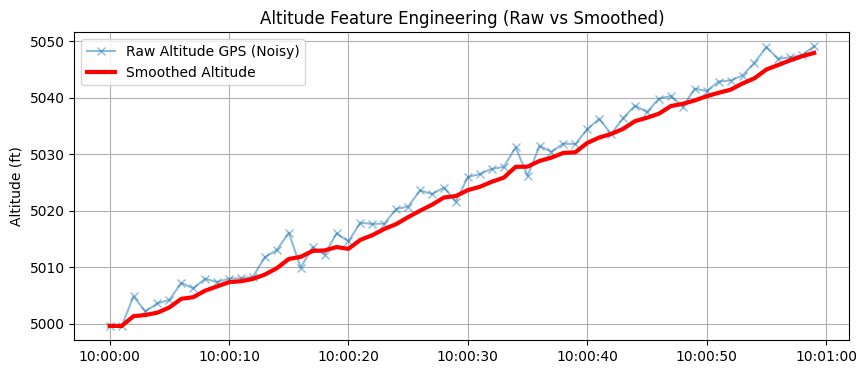

Calculating altitude gain explicitly for the window:
Total Window Gain: 48.29 feet


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

# Append parent dir so we can test imports from our training package
sys.path.append(os.path.abspath('..'))

try:
    from training.feature_extractor import FeatureExtractor
    print("Successfully imported FeatureExtractor from src!")
except ImportError:
    print("FeatureExtractor module not fully wired – running inline demonstration logic instead.")

print('---')
print('Generating a 60-second synthetic trekking GPS window...')

# Let's generate a synthetic trajectory window to test feature extraction
timestamps = pd.date_range("2026-04-04 10:00:00", periods=60, freq="1S")

# Synthetic realistic trekking profile (moving up a slight hill)
lat = np.linspace(40.0, 40.005, 60) + np.random.normal(0, 0.0001, 60)
lon = np.linspace(-105.0, -105.002, 60) + np.random.normal(0, 0.0001, 60)
alt = np.linspace(5000, 5050, 60) + np.random.normal(0, 1.5, 60)

df_window = pd.DataFrame({
    'timestamp': timestamps,
    'lat': lat,
    'lon': lon,
    'altitude': alt
})

display(df_window.head())

# Visualizing the raw vs processed feature
plt.figure(figsize=(10, 4))
plt.plot(df_window['timestamp'], df_window['altitude'], label="Raw Altitude GPS (Noisy)", marker="x", alpha=0.5)

# Emulate a basic rolling window filter (similar to Kalman/Lowpass logic used in engineering)
df_window['alt_smooth'] = df_window['altitude'].rolling(window=5, min_periods=1).mean()
plt.plot(df_window['timestamp'], df_window['alt_smooth'], label="Smoothed Altitude", linewidth=3, color='red')

plt.title("Altitude Feature Engineering (Raw vs Smoothed)")
plt.ylabel("Altitude (ft)")
plt.legend()
plt.grid(True)
plt.show()

print("Calculating altitude gain explicitly for the window:")
total_gain = df_window['alt_smooth'].iloc[-1] - df_window['alt_smooth'].iloc[0]
print(f"Total Window Gain: {total_gain:.2f} feet")